# Define paths

In [1]:
# To run this model notebook, first run Elias_create_train_val_test_datasets.ipynb to create the datasets, then copy the printed paths and paste them below

train_data_dir = '/Users/et/code/Lucia-Cordero/ReefSight-Project/raw_data/image_data/train_validation_test/train'
val_data_dir = '/Users/et/code/Lucia-Cordero/ReefSight-Project/raw_data/image_data/train_validation_test/val'
test_data_dir = '/Users/et/code/Lucia-Cordero/ReefSight-Project/raw_data/image_data/train_validation_test/test'

# Additionally, define path to save model
model_path = '/Users/et/code/Lucia-Cordero/ReefSight-Project/models'

# Baseline reg aug model

In [2]:
# Load data using image_dataset_from_directory
from tensorflow.keras.utils import image_dataset_from_directory

batch_size = 16
seed = 42
image_size = (224, 224)

# Load datasets
train_ds = image_dataset_from_directory(
    train_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    val_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

test_ds = image_dataset_from_directory(
    test_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

print("Class names train dataset:", train_ds.class_names)
print("Class names validation dataset:", val_ds.class_names)
print("Class names test dataset:", test_ds.class_names)

Found 540 files belonging to 2 classes.
Found 179 files belonging to 2 classes.
Found 182 files belonging to 2 classes.
Class names train dataset: ['Bleached', 'Unbleached']
Class names validation dataset: ['Bleached', 'Unbleached']
Class names test dataset: ['Bleached', 'Unbleached']


In [3]:
# Built and compile baseline reg aug CNN model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import layers, optimizers, Input, regularizers

image_size = (224, 224)
input_shape = image_size + (3,)
num_classes = 2
learning_rate = 0.003

def create_baseline_reg_aug_cnn(input_shape, num_classes=2, learning_rate=0.001):

    # Build the model
    model = Sequential()

    # Add a data augmentation layer
    model.add(layers.RandomFlip("horizontal_and_vertical", input_shape=input_shape))
    model.add(layers.RandomRotation(0.2))
    model.add(layers.RandomZoom(0.2))
    model.add(layers.RandomBrightness(0.2))
    model.add(layers.RandomContrast(0.2))
    model.add(layers.GaussianNoise(0.1))

    # Normalize pixel values to [0,1]
    model.add(layers.Rescaling(1./255))

    # Convolutional Layers
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding="same", kernel_regularizer=regularizers.l2(0.007)))
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding="same", kernel_regularizer=regularizers.l2(0.007)))
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding="same", kernel_regularizer=regularizers.l2(0.007)))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Flatten())

    # Dropout and Batch Normalization
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    # Output Layer
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile the model
    adam = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=adam, loss='binary_crossentropy', metrics=['accuracy'])

    return model

baseline_reg_aug_model = create_baseline_reg_aug_cnn(input_shape, num_classes, learning_rate)
baseline_reg_aug_model.summary()

/Users/et/.pyenv/versions/3.10.6/envs/ReefSight-Project/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,161 (24.86 MB)

 Trainable params: 6,516,033 (24.86 MB)

 Non-trainable params: 128 (512.00 B)

In [4]:
# Train the baseline reg aug model using tf.data `train_ds` and `val_ds`

import os

# Configure callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                     patience=10,
                                     restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(os.path.join(model_path, 'baseline_reg_aug_image_model.keras'),
                                       monitor='val_accuracy',
                                       save_best_only=True), # What does ModelCheckpoint do?
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy',
                                         factor=0.5,
                                         patience=2,
                                         verbose=1), # What does ReduceLROnPlateau do?
]

# Train using datasets
epochs = 1000

history = baseline_reg_aug_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks,
)

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 194ms/step - accuracy: 0.5667 - loss: 1.3711 - val_accuracy: 0.6760 - val_loss: 1.1368 - learning_rate: 0.0030
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.5704 - loss: 1.0548 - val_accuracy: 0.5028 - val_loss: 1.1799 - learning_rate: 0.0030
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.6480 - loss: 0.9165
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.6333 - loss: 0.8939 - val_accuracy: 0.4804 - val_loss: 1.0995 - learning_rate: 0.0030
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.6389 - loss: 0.7980 - val_accuracy: 0.7318 - val_loss: 0.7306 - learning_rate: 0.0015
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.6574 - loss: 0.7675 - val_accuracy: 0.7039 - val_loss: 0.6951 - learning_rate: 0.0015
Epoch 6/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.6434 - loss:

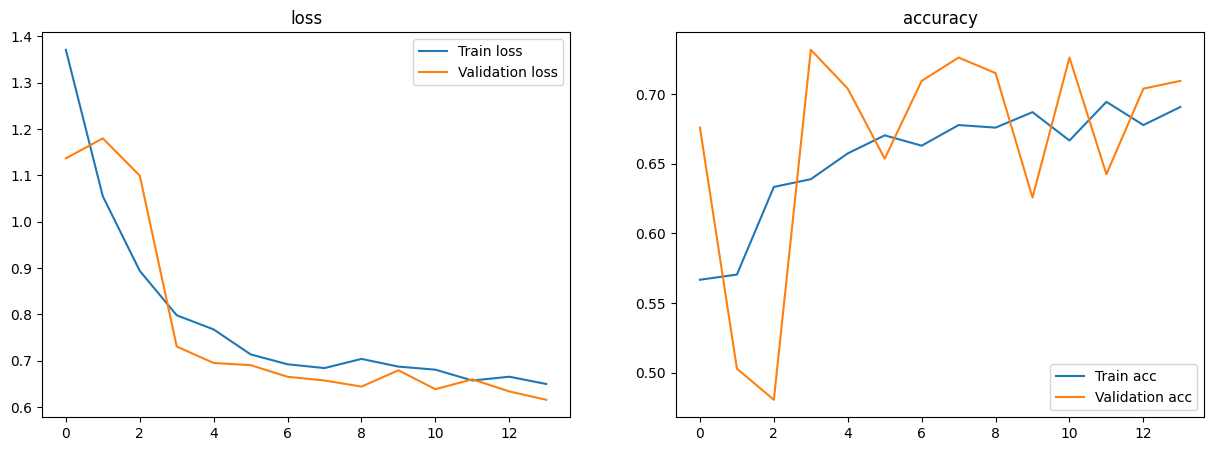

In [5]:
import matplotlib.pyplot as plt

# Plot training history

def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].set_title('loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
    ax[1].set_title('accuracy')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation acc")
    ax[0].legend()
    ax[1].legend()

plot_history(history)

In [6]:
# Evaluate the model on the val dataset

test_loss, test_accuracy = baseline_reg_aug_model.evaluate(val_ds)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


# Evaluate the model on the test dataset

test_loss, test_accuracy = baseline_reg_aug_model.evaluate(test_ds)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7318 - loss: 0.7306
Test Loss: 0.73060542345047
Test Accuracy: 0.7318435907363892
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7198 - loss: 0.7241
Test Loss: 0.7241388559341431
Test Accuracy: 0.7197802066802979


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


2025-12-14 12:19:16.534676: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


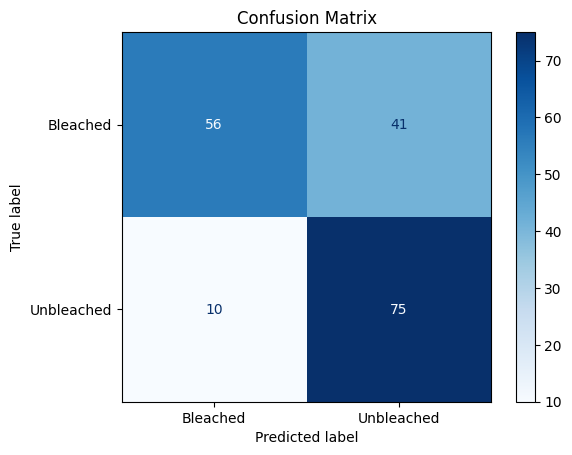

In [7]:
# Plot confusion matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

# Iterate through the test dataset to collect predictions
for images, labels in test_ds:
    y_true.extend(labels)  # Assuming labels are already in a format compatible with y_true
    predictions = baseline_reg_aug_model.predict(images)
    # For binary classification, use a threshold of 0.5 to determine class
    predicted_class = (predictions > 0.5).astype(int)  # Convert probabilities to class labels
    y_pred.extend(predicted_class)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_ds.class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Predict from saved model

In [8]:
model_loaded = tf.keras.models.load_model(os.path.join('/Users/et/code/Lucia-Cordero/ReefSight-Project/models', 'baseline_reg_aug_image_model.keras'))
model_loaded.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,548,229 (74.57 MB)

 Trainable params: 6,516,033 (24.86 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 13,032,068 (49.71 MB)

# Predictions

Randomly selected image: 4767456872_e9c7a580b9_o.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Probability Unbleached: 0.661733090877533
Probability Bleached: 0.33826690912246704
Predicted class index: 1
Class names test dataset: ['Bleached', 'Unbleached']
Predicted class: Unbleached


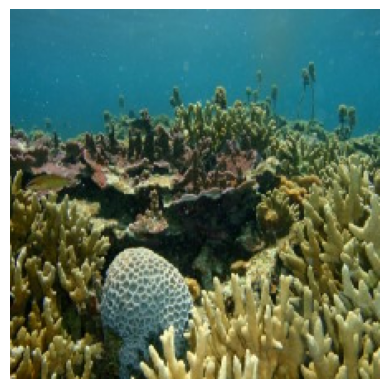

In [9]:
# Make predictions on a single image from the test dataset
from tensorflow.keras.preprocessing import image
import random

# List all files in the directory
image_files_bleached = [f for f in os.listdir(test_data_dir + '/Bleached') if os.path.isfile(os.path.join(test_data_dir + '/Bleached', f))]
image_files_unbleached = [f for f in os.listdir(test_data_dir + '/Unbleached') if os.path.isfile(os.path.join(test_data_dir + '/Unbleached', f))]

# Select a random image file
random_image = random.choice(image_files_bleached)

print(f'Randomly selected image: {random_image}')

# Load the image
img_path = test_data_dir + '/Bleached/' + random_image
img = image.load_img(img_path, target_size=(224, 224))
img.convert('RGB')  # Ensure image is in RGB format
img_array = image.img_to_array(img)
#img_array /= 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
predictions = model_loaded.predict(img_array)
print(f"Probability Unbleached: {predictions[0][0]}")
print(f"Probability Bleached: {1-predictions[0][0]}")

predicted_class = (predictions[0][0] >= 0.5).astype("int32")
print(f"Predicted class index: {predicted_class}")

class_names = test_ds.class_names
print(f"Class names test dataset:", test_ds.class_names)

predicted_label = class_names[predicted_class]
print(f"Predicted class: {predicted_label}")

# Visualize the image
plt.imshow(img)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
True classes: ['Unbleached', 'Bleached', 'Bleached', 'Bleached', 'Bleached', 'Unbleached', 'Bleached', 'Bleached', 'Unbleached', 'Bleached', 'Bleached', 'Bleached', 'Bleached', 'Bleached', 'Unbleached', 'Unbleached']
Predicted classes: ['Unbleached', 'Bleached', 'Bleached', 'Bleached', 'Bleached', 'Unbleached', 'Bleached', 'Bleached', 'Unbleached', 'Bleached', 'Unbleached', 'Bleached', 'Bleached', 'Unbleached', 'Unbleached', 'Unbleached']


/var/folders/d9/v5_06vd52pj5h82bcx8qbzbm0000gn/T/ipykernel_3452/1183402069.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob_unbleached = float(preds[i])


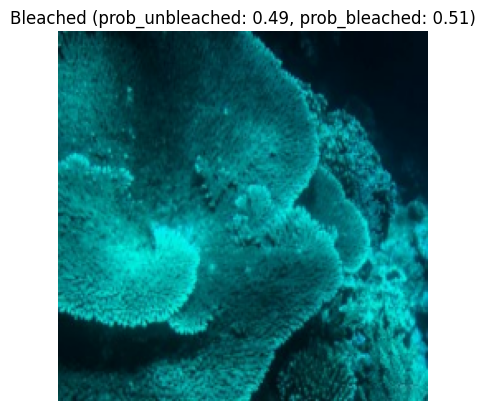

In [10]:
# Alternatively, make predictions on a batch of images from the test dataset

#Displaying predicstions vs true labels for 1 batch in test_set
for images, labels in test_ds.take(1):
    preds = model_loaded.predict(images)
    # Convert tensors to arrays
    true_labels = labels.numpy().astype(int).reshape(-1)
    pred_labels = (preds > 0.5).astype(int).reshape(-1)
    probs = preds.reshape(-1) # flattent to 1D
    break
# Map numeric labels → class names
class_names = test_ds.class_names
true_class_names = [class_names[i] for i in true_labels]
pred_class_names = [class_names[i] for i in pred_labels]
print("True classes:", true_class_names)
print("Predicted classes:", pred_class_names)


#Displaying one image with readable class names
import matplotlib.pyplot as plt
i = 11  # choose image index
pred_class_name = class_names[pred_labels[i]]
prob_unbleached = float(preds[i])
prob_bleached = 1 - prob_unbleached
plt.imshow(images[i].numpy().astype("uint8"))
plt.title(f"{pred_class_name} (prob_unbleached: {prob_unbleached:.2f}, prob_bleached: {prob_bleached:.2f})")
plt.axis("off")
plt.show()